In [2]:
import pandas as pd
import matplotlib.pylab as plt
from sklearn.compose import ColumnTransformer
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer


In [3]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment('APU_model_experiments')

2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/25 12:09:31 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/25 12:09:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/25 12:09:33 INFO mlflow.store.db.utils: Updating database tables
2026/02/25 12:09:33 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/25 12:09:33 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/25 12:09:33 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/02/25 12:0

<Experiment: artifact_location='file:///e:/APU_Predictive_Maintenance/NoteBook/Models_experimemts/mlruns/1', creation_time=1772001575332, experiment_id='1', last_update_time=1772001575332, lifecycle_stage='active', name='APU_model_experiments', tags={}>

In [4]:
train_path = r'E:\APU_Predictive_Maintenance\Artifacts\preprocessed\train_preprocessed\train_preprocessed.csv'
test_path = r'E:\APU_Predictive_Maintenance\Artifacts\preprocessed\test_preprocessed\\test_preprocessed.csv'

In [5]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15_trend,sensor_17_rolling_mean,sensor_17_rolling_std,sensor_17_trend,sensor_20_rolling_mean,sensor_20_rolling_std,sensor_20_trend,sensor_21_rolling_mean,sensor_21_rolling_std,sensor_21_trend
0,1,-1.57053,0.746493,0.864455,0.417725,-0.889706,-0.291006,-0.187969,0.537852,-0.706737,...,-0.004952,-0.053141,-0.840616,-0.004565,-0.908486,-0.832405,0.002646,-1.561555,-0.830872,0.002677
1,1,-1.57053,0.746493,0.864455,0.417725,-0.889706,-0.291006,-0.187969,0.537852,-0.706737,...,-0.004952,-0.053141,-0.840616,-0.004565,-0.908486,-0.832405,0.002646,-1.561555,-0.830872,0.002677
2,1,-1.57053,0.746493,0.864455,0.417725,-0.889706,-0.291006,-0.187969,0.537852,-0.706737,...,-0.004952,-0.053141,-0.840616,-0.004565,-0.908486,-0.832405,0.002646,-1.561555,-0.830872,0.002677
3,1,-1.57053,0.746493,0.864455,0.417725,-0.889706,-0.291006,2.064381,0.537852,-0.706737,...,-0.004952,-0.053141,-0.840616,-0.004565,-0.908486,-0.832405,0.002646,-1.561555,-0.830872,0.002677
4,1,-1.57053,0.746493,0.864455,0.417725,-0.889706,-0.291006,-0.187969,0.537852,-0.706737,...,-0.004952,-0.053141,-0.840616,-0.004565,-0.908486,-0.832405,0.002646,-1.561555,-0.830872,0.002677


In [6]:
train_df.shape, test_df.shape

((257334, 74), (65220, 74))

In [7]:
train_df.columns


Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'anomaly_score', 'fault_label', 'fault_type', 'fault_target', 'RUL',
       'cycle_normalized', 'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_2_trend', 'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_3_trend', 'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_4_trend', 'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_7_trend', 'sensor_8_rolling_mean', 'sensor_8_rolling_std',
       'sensor_8_trend', 'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_9_trend', 'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_11_trend', 'sensor

In [8]:
test_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'anomaly_score', 'fault_label', 'fault_type', 'fault_target', 'RUL',
       'cycle_normalized', 'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_2_trend', 'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_3_trend', 'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_4_trend', 'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_7_trend', 'sensor_8_rolling_mean', 'sensor_8_rolling_std',
       'sensor_8_trend', 'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_9_trend', 'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_11_trend', 'sensor

In [9]:
DROP_COLS = [
    "engine_id",
    "RUL",
    "fault_label",
    "fault_type",
    "fault_target"
]

In [10]:
x_train = train_df.drop(columns=[x for x in DROP_COLS if x in train_df.columns])
y_train = train_df['RUL']

x_test = test_df.drop(columns=[x for x in DROP_COLS if x in test_df.columns])
y_test = test_df['RUL']

In [11]:
x_train.columns

Index(['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'anomaly_score',
       'cycle_normalized', 'sensor_2_rolling_mean', 'sensor_2_rolling_std',
       'sensor_2_trend', 'sensor_3_rolling_mean', 'sensor_3_rolling_std',
       'sensor_3_trend', 'sensor_4_rolling_mean', 'sensor_4_rolling_std',
       'sensor_4_trend', 'sensor_7_rolling_mean', 'sensor_7_rolling_std',
       'sensor_7_trend', 'sensor_8_rolling_mean', 'sensor_8_rolling_std',
       'sensor_8_trend', 'sensor_9_rolling_mean', 'sensor_9_rolling_std',
       'sensor_9_trend', 'sensor_11_rolling_mean', 'sensor_11_rolling_std',
       'sensor_11_trend', 'sensor_12_rolling_mean', 'sensor_12_rolling_std',
       'sensor_12_trend', 's

In [12]:
y_train

0         148
1         148
2         148
3         148
4         148
         ... 
257329      0
257330      0
257331      0
257332      0
257333      0
Name: RUL, Length: 257334, dtype: int64

In [13]:
x_test

,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_15_trend,sensor_17_rolling_mean,sensor_17_rolling_std,sensor_17_trend,sensor_20_rolling_mean,sensor_20_rolling_std,sensor_20_trend,sensor_21_rolling_mean,sensor_21_rolling_std,sensor_21_trend
0,-1.57053,-1.627251,-1.845178,0.417725,1.734366,-0.020725,-0.013357,-0.465220,1.823473,1.843139,...,-0.004952,0.188998,-0.840616,-0.004565,0.197959,-0.832405,0.002646,-1.470298,-0.830872,0.002677
1,-1.57053,-1.627251,-1.845178,0.417725,1.734366,-0.020725,-0.013357,-0.465220,1.823473,1.843139,...,-0.004952,0.188998,-0.840616,-0.004565,0.197959,-0.832405,0.002646,-1.470298,-0.830872,0.002677
2,-1.57053,-1.627251,-1.845178,0.417725,1.734366,-0.020725,-0.013357,-0.465220,1.823473,1.843139,...,-0.004952,0.188998,-0.840616,-0.004565,0.197959,-0.832405,0.002646,-1.470298,-0.830872,0.002677
3,-1.57053,-1.627251,-1.845178,0.417725,1.734366,-0.020725,-0.991147,-0.465220,1.823473,1.843139,...,-0.004952,0.188998,-0.840616,-0.004565,0.197959,-0.832405,0.002646,-1.470298,-0.830872,0.002677
4,-1.57053,-1.627251,-1.845178,0.417725,1.734366,-0.020725,-0.013357,-0.465220,1.823473,1.843139,...,-0.004952,0.188998,-0.840616,-0.004565,0.197959,-0.832405,0.002646,-1.470298,-0.830872,0.002677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65215,3.03163,0.746852,0.864455,0.417725,-0.889706,3.517159,0.074556,1.011526,-0.706737,-0.661672,...,-0.004952,1.521176,1.638142,-0.004565,0.155335,0.046766,0.002646,-1.145736,0.640454,0.002677
65216,3.03163,0.746852,0.864455,0.417725,-0.889706,-0.523023,0.074556,3.441657,-0.706737,-0.661672,...,-0.004952,1.848680,1.638142,-0.004565,0.019975,0.046766,0.002646,-0.918998,0.640454,0.002677
65217,3.03163,0.746852,0.864455,0.417725,-0.889706,-0.523023,0.023167,1.011526,-0.706737,-0.661672,...,-0.004952,2.176184,1.183282,-0.004565,-0.115386,-0.114565,0.002646,-0.692260,0.370460,0.002677
65218,3.03163,0.746852,0.864455,0.417725,-0.889706,-0.523023,0.074556,1.011526,-0.706737,-0.661672,...,-0.004952,2.503688,-0.840616,-0.004565,-0.250747,-0.832405,0.002646,-0.465522,-0.830872,0.002677


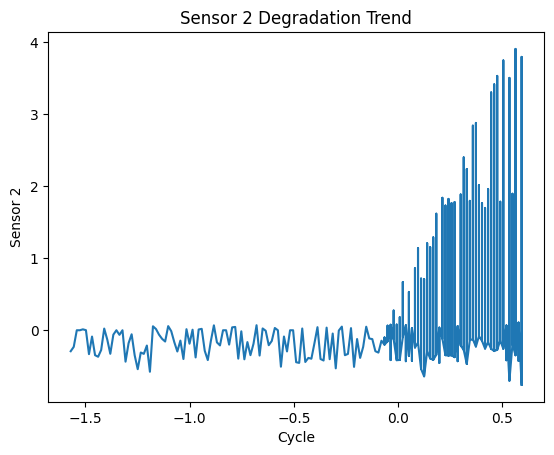

In [14]:

# choose one engine to visualize
engine_id = train_df["engine_id"].iloc[0]

engine_data = train_df[train_df["engine_id"] == engine_id]

plt.figure()
plt.plot(engine_data["cycle"], engine_data["sensor_2"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Degradation Trend")
plt.show()

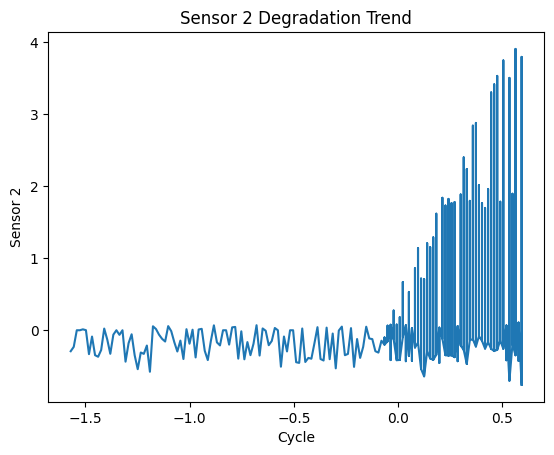

In [15]:

# choose one engine to visualize
engine_id = train_df["engine_id"].iloc[0]

engine_data = train_df[train_df["engine_id"] == engine_id]

plt.figure()
plt.plot(engine_data["cycle"], engine_data["sensor_2"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 Degradation Trend")
plt.show()

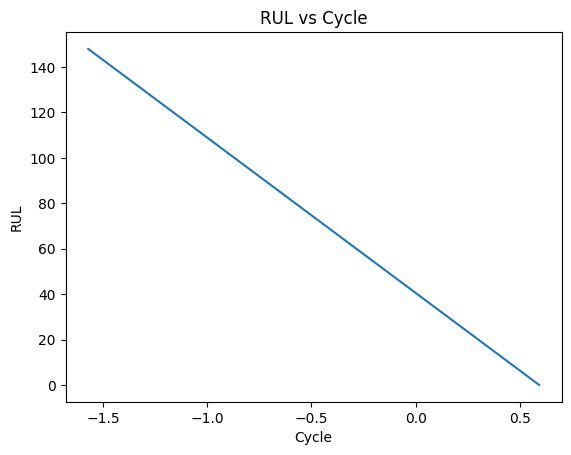

In [16]:
plt.figure()
plt.plot(engine_data["cycle"], engine_data["RUL"])
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL vs Cycle")
plt.show()

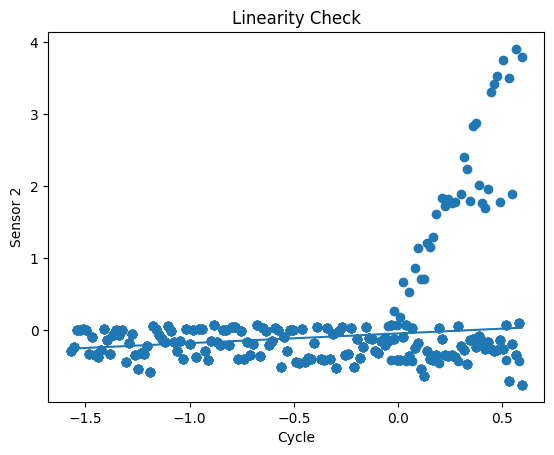

In [17]:
import numpy as np
x = engine_data["cycle"]
y = engine_data["sensor_2"]

plt.figure()
plt.scatter(x, y)

# regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Linearity Check")
plt.show()

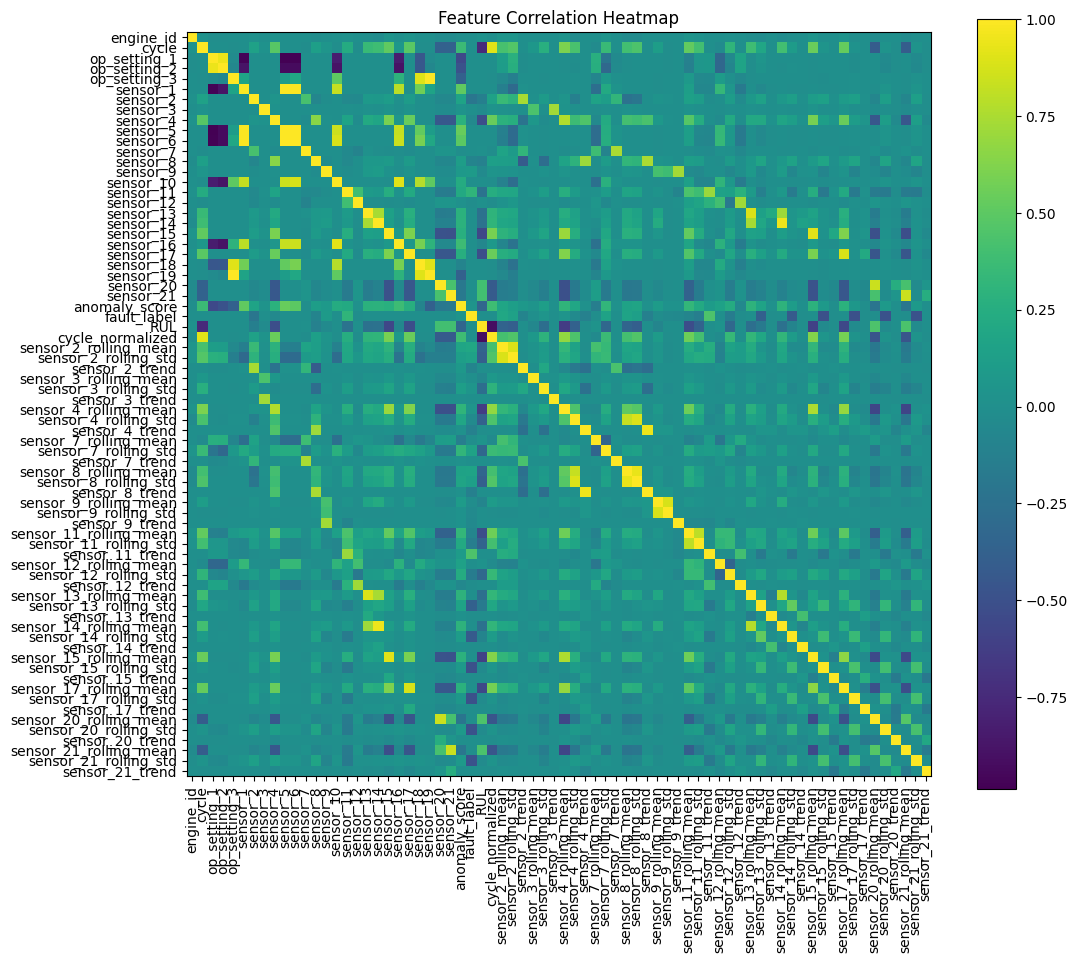

In [18]:
# select numeric columns only
numeric_df = train_df.select_dtypes(include=["number"])

# compute correlation
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

<Axes: xlabel='RUL', ylabel='Count'>

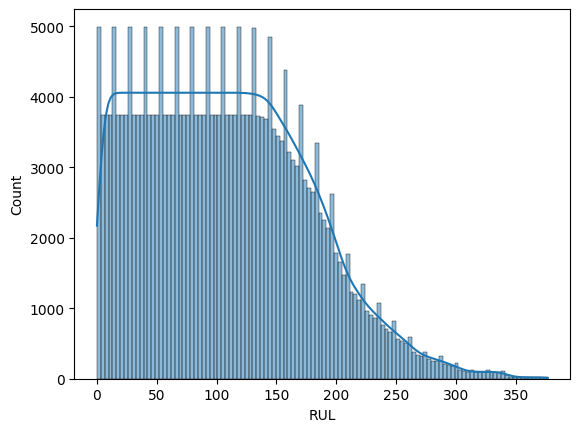

In [19]:
import seaborn as sns
sns.histplot(train_df["RUL"], kde=True)

In [20]:
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mse, mae, r2, rmse

In [21]:
models = {
    'LinearRegression' : LinearRegression(), 
    'ridge' : Ridge(),
    'Lasso' : Lasso(),
    'KNN' : KNeighborsRegressor(),
    'DecisionTree' : DecisionTreeRegressor(),
    'AdaBoostRegressor' : AdaBoostRegressor(),
    'RandomForestRegressor' : RandomForestRegressor(),
    'GradientBoostingRegressor' : GradientBoostingRegressor(),
    'LGBMRegressor' : LGBMRegressor(),
    'XGBRegressor' : XGBRegressor()
}

In [22]:
best_rmse = float("inf")
best_model_name = None
best_model = None

for name, model in models.items():
    with mlflow.start_run(run_name=name):

        print(f"\nTraining {name}...")
        model.fit(x_train, y_train)
    
        y_train_pred  = model.predict(x_train)
        y_test_pred = model.predict(x_test)
    
        model_tr_mse, model_tr_mae, model_tr_r2, model_tr_rmse = evaluate_model(y_train, y_train_pred)
        model_ts_mse, model_ts_mae, model_ts_r2, model_ts_rmse = evaluate_model(y_test, y_test_pred)
        
        
        mlflow.log_metrics({
            'train_mse' : model_tr_mse,
            'train_mae' : model_tr_mae,
            'train_r2' : model_tr_r2,
            'train_rmse' : model_tr_rmse,   
            
            'test_mse' : model_ts_mse,
            'test_mae' : model_ts_mae,
            'test_r2' : model_ts_r2,
            'test_rmse' : model_ts_rmse,       
        })
        
        mlflow.log_params(model.get_params())
                         
        mlflow.sklearn.log_model(model, 'model')
        
        if model_tr_rmse < best_rmse:
            best_rmse = model_tr_rmse
            best_model = model
            best_model_name = name
            
        print('-------------------------------------------------------------')
        
        print('model selection for training dtaset for ->', name)
        print('mean square error : {:.4f}'.format(model_tr_mse))
        print('mean absoulate error : {:.4f}'.format(model_tr_mae))
        print('r2 score : {:.4f}'.format(model_tr_r2))
        print('root mean square error : {:.4f}'.format(model_tr_rmse))
        
        print('-------------------------------------------------------------')
        
        print('model selection for testg dtaset for ->', name)
        print('mean square error : {:.4f}'.format(model_ts_mse))
        print('mean absoulate error : {:.4f}'.format(model_ts_mae))
        print('r2 score : {:.4f}'.format(model_ts_r2))
        print('root mean square error : {:.4f}'.format(model_ts_rmse))
        
print("\nBest Baseline Model:", best_model_name)


Training LinearRegression...


2026/02/25 12:09:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


-------------------------------------------------------------
model selection for training dtaset for -> LinearRegression
mean square error : 585.5584
mean absoulate error : 16.0361
r2 score : 0.8750
root mean square error : 24.1983
-------------------------------------------------------------
model selection for testg dtaset for -> LinearRegression
mean square error : 785.4313
mean absoulate error : 19.1700
r2 score : 0.8483
root mean square error : 28.0255

Training ridge...


2026/02/25 12:10:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


-------------------------------------------------------------
model selection for training dtaset for -> ridge
mean square error : 585.5828
mean absoulate error : 16.0380
r2 score : 0.8750
root mean square error : 24.1988
-------------------------------------------------------------
model selection for testg dtaset for -> ridge
mean square error : 785.3854
mean absoulate error : 19.1684
r2 score : 0.8483
root mean square error : 28.0247

Training Lasso...


...

-------------------------------------------------------------
model selection for training dtaset for -> GradientBoostingRegressor
mean square error : 104.0337
mean absoulate error : 5.6511
r2 score : 0.9778
root mean square error : 10.1997
-------------------------------------------------------------
model selection for testg dtaset for -> GradientBoostingRegressor
mean square error : 150.7988
mean absoulate error : 7.0088
r2 score : 0.9709
root mean square error : 12.2800

Training LGBMRegressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15457
[LightGBM] [Info] Number of data points in the train set: 257334, number of used features: 69
[LightGBM] [Info] Start training from score 107.496677


2026/02/25 12:53:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


-------------------------------------------------------------
model selection for training dtaset for -> LGBMRegressor
mean square error : 10.2089
mean absoulate error : 1.7138
r2 score : 0.9978
root mean square error : 3.1951
-------------------------------------------------------------
model selection for testg dtaset for -> LGBMRegressor
mean square error : 27.2135
mean absoulate error : 2.2402
r2 score : 0.9947
root mean square error : 5.2167

Training XGBRegressor...


2026/02/25 12:54:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


-------------------------------------------------------------
model selection for training dtaset for -> XGBRegressor
mean square error : 5.6867
mean absoulate error : 1.5773
r2 score : 0.9988
root mean square error : 2.3847
-------------------------------------------------------------
model selection for testg dtaset for -> XGBRegressor
mean square error : 26.3153
mean absoulate error : 2.3159
r2 score : 0.9949
root mean square error : 5.1298

Best Baseline Model: DecisionTree


In [23]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:///mlflow.db


In [24]:
LGBM_params = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 5, 10, 15],
    "num_leaves": [31, 50, 70, 100],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_samples": [10, 20, 30, 50]
}


In [25]:
lgbm =LGBMRegressor(random_state=42, force_col_wise=True)

rmse_scorer =  make_scorer(
    lambda y_true, y_pred: np.sqrt(np.mean((y_true - y_pred) ** 2)),
    greater_is_better=False
)


In [26]:
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=LGBM_params,
    n_iter=20,
    scoring=rmse_scorer,
    cv = 3,
    verbose=2,
    random_state=42, 
    n_jobs=-1,
    error_score="raise"
)

In [27]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

with mlflow.start_run(run_name="LGBM_Hyperparameter_Tuning"):
    
    random_search.fit(x_train, y_train)
    
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    
    
    y_pred = best_model.predict(x_test)
    test_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    
    print("\n Best Hyperparameters:", best_params)
    
    print("\nFinal RMSE:", test_rmse)
    
    mlflow.log_params(best_params)
    mlflow.log_metric('RMSE', test_rmse)

    mlflow.sklearn.log_model(best_model, "LGBM_best_model")
    

    

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Total Bins 15456
[LightGBM] [Info] Number of data points in the train set: 257334, number of used features: 69
[LightGBM] [Info] Start training from score 107.496677

 Best Hyperparameters: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Final RMSE: 4.711093611791125


2026/02/25 13:06:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 13:06:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [29]:
lgbm_model = LGBMRegressor(n_estimators=400,  learning_rate=0.05,  max_depth=-1, num_leaves=50, subsample=1.0,  colsample_bytree=1.0, min_child_samples=20)
lgbm_model.fit(x_train, y_train)
y_pred = lgbm_model.predict(x_test)


print('mean square error :', mean_squared_error(y_test, y_pred))
print('mean absoulate error : {:.4f}'.format(mean_absolute_error(y_test, y_pred)))
print('r2 score : {:.4f}'.format(r2_score(y_test, y_pred)))
print('root mean square error : {:.4f}'.format(np.sqrt(mean_squared_error(y_test, y_pred))))
        


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15457
[LightGBM] [Info] Number of data points in the train set: 257334, number of used features: 69
[LightGBM] [Info] Start training from score 107.496677
mean square error : 22.642707236507842
mean absoulate error : 1.7215
r2 score : 0.9956
root mean square error : 4.7584
